In [2]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    auc, confusion_matrix, ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", exc)

RANDOM_STATE = 42

possible_folders = [Path.cwd(), Path.cwd() / "Data Science", Path.home() / "Desktop" / "Data Science"]
project_folder = next(
    (folder.resolve() for folder in possible_folders if (folder / "Fire2Air_model_ready_checkpoint.csv").exists()),
    None,
)
if project_folder is None:
    raise FileNotFoundError("Fire2Air_model_ready_checkpoint.csv not found. Run Thi's notebook first.")

output_root = project_folder / "outputs_prt661"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
model_dir = output_root / "models"
for folder in [table_dir, figure_dir, model_dir]:
    folder.mkdir(parents=True, exist_ok=True)

integrated_daily = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint.csv",
    parse_dates=["date", "target_date"],
)

manifest_path = project_folder / "Fire2Air_feature_manifest.json"
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)
model_features = manifest["features"]
classification_target = manifest["targets"]["classification"]

print("Project folder:", project_folder)
print("Dataset shape:", integrated_daily.shape)
print("Shared predictors:", len(model_features))

XGBoost unavailable: No module named 'xgboost'
Project folder: C:\Users\dlihi\Documents\PRT661 Data Science\Assessment 2\PRT661---DATA-SCIENCE-PRACTICE---Dan5---Theme2\Source code
Dataset shape: (7530, 58)
Shared predictors: 22


## A Chronological Split & Class Balance
Training = target years 2018–2022, validation = target year 2023, final test = target year 2024.

In [3]:
classification_data = integrated_daily.dropna(
    subset=[classification_target, "target_date"]
).copy()
classification_data[classification_target] = classification_data[classification_target].astype(int)
classification_data["target_year"] = classification_data["target_date"].dt.year

train_cls = classification_data[classification_data["target_year"] <= 2022].copy()
validation_cls = classification_data[classification_data["target_year"] == 2023].copy()
test_cls = classification_data[classification_data["target_year"] == 2024].copy()

if min(len(train_cls), len(validation_cls), len(test_cls)) == 0:
    raise ValueError(
        f"Insufficient chronological data: train={len(train_cls)}, "
        f"validation={len(validation_cls)}, test={len(test_cls)}"
    )

assert train_cls["target_date"].max() < validation_cls["target_date"].min()
assert validation_cls["target_date"].max() < test_cls["target_date"].min()

balance_rows = []
for split_name, data in [("Train", train_cls), ("Validation", validation_cls), ("Test", test_cls)]:
    positives = int(data[classification_target].sum())
    balance_rows.append({
        "Split": split_name,
        "Rows": len(data),
        "Positive_Days": positives,
        "Positive_Rate": positives / len(data),
    })
class_balance = pd.DataFrame(balance_rows)
print("\nClass balance:")
print(class_balance.round(4).to_string(index=False))
class_balance.to_csv(table_dir / "model1_class_balance.csv", index=False)

X_train = train_cls[model_features]
y_train = train_cls[classification_target]
X_validation = validation_cls[model_features]
y_validation = validation_cls[classification_target]
X_test = test_cls[model_features]
y_test = test_cls[classification_target]


Class balance:
     Split  Rows  Positive_Days  Positive_Rate
     Train  4546            217         0.0477
Validation   946            100         0.1057
      Test   863             37         0.0429


## Preprocessing & Metrics

In [5]:
categorical_features = ["station"]
numeric_features = [f for f in model_features if f not in categorical_features]

def onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot()),
])

logistic_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

tree_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logistic_preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", logistic_numeric_pipeline, numeric_features),
])

tree_preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", tree_numeric_pipeline, numeric_features),
])

def probability_metrics(y_true, probabilities):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, probabilities)
    return {
        "PR_AUC": auc(recall_curve, precision_curve),
        "Average_Precision": average_precision_score(y_true, probabilities),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
    }

def threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
    }

def find_best_threshold(y_true, probabilities):
    thresholds = np.arange(0.01, 1.00, 0.01)
    scores = [
        f1_score(y_true, (probabilities >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

## Candidate models and PR-AUC-first tuning


In [6]:
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = neg / max(pos, 1)

configurations = []

for c_value in [0.01, 0.1, 1.0, 10.0]:
    configurations.append((
        "Logistic Regression",
        f"C={c_value}",
        Pipeline([
            ("preprocessor", logistic_preprocessor),
            ("model", LogisticRegression(
                C=c_value,
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )),
        ]),
    ))

for max_depth, min_samples_leaf in [(None, 1), (None, 4), (10, 4), (15, 4)]:
    configurations.append((
        "Random Forest",
        f"max_depth={max_depth};min_samples_leaf={min_samples_leaf}",
        Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
    ))

if HAS_XGBOOST:
    for n_estimators, learning_rate, max_depth in [
        (100, 0.05, 2), (200, 0.05, 2), (200, 0.05, 3), (300, 0.05, 3)
    ]:
        configurations.append((
            "XGBoost",
            f"n_estimators={n_estimators};learning_rate={learning_rate};max_depth={max_depth}",
            Pipeline([
                ("preprocessor", tree_preprocessor),
                ("model", XGBClassifier(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    scale_pos_weight=scale_pos_weight,
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
        ))

validation_rows = []
trained_templates = {}

for model_family, config_id, pipeline in configurations:
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_validation)[:, 1]
    threshold, best_f1 = find_best_threshold(y_validation, probabilities)
    row = {
        "Model": model_family,
        "Config": config_id,
        "Threshold": threshold,
        **probability_metrics(y_validation, probabilities),
        **threshold_metrics(y_validation, probabilities, threshold),
    }
    validation_rows.append(row)
    trained_templates[(model_family, config_id)] = pipeline

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["PR_AUC", "F1"], ascending=[False, False]
).reset_index(drop=True)

print("\nAll 2023 validation configurations — ranked by PR-AUC:")
print(validation_results.round(4).to_string(index=False))
validation_results.to_csv(table_dir / "model1_classification_validation_results.csv", index=False)

best_by_family = (
    validation_results.sort_values(["PR_AUC", "F1"], ascending=[False, False])
    .groupby("Model", as_index=False)
    .first()
    .sort_values(["PR_AUC", "F1"], ascending=[False, False])
    .reset_index(drop=True)
)
print("\nBest configuration from each family:")
print(best_by_family.round(4).to_string(index=False))

selected = best_by_family.iloc[0]
best_model_name = selected["Model"]
best_config_id = selected["Config"]
final_threshold = float(selected["Threshold"])
selected_template = trained_templates[(best_model_name, best_config_id)]

print("\nSelected model by validation PR-AUC:", best_model_name)
print("Selected configuration:", best_config_id)
print("F1-optimised validation threshold:", round(final_threshold, 3))


All 2023 validation configurations — ranked by PR-AUC:
              Model                            Config  Threshold  PR_AUC  Average_Precision  ROC_AUC  Accuracy  Precision  Recall     F1
Logistic Regression                             C=0.1       0.78  0.7275             0.7290   0.9486    0.9260     0.6271    0.74 0.6789
Logistic Regression                             C=1.0       0.80  0.7187             0.7201   0.9412    0.9302     0.6667    0.68 0.6733
Logistic Regression                            C=10.0       0.81  0.7184             0.7197   0.9396    0.9313     0.6804    0.66 0.6701
Logistic Regression                            C=0.01       0.78  0.7075             0.7101   0.9529    0.9313     0.6378    0.81 0.7137
      Random Forest max_depth=None;min_samples_leaf=1       0.13  0.6779             0.6803   0.9484    0.9197     0.5800    0.87 0.6960
      Random Forest max_depth=None;min_samples_leaf=4       0.30  0.6528             0.6572   0.9464    0.9228     0.5971 

## Refit on 2018–2023 and evaluate once on untouched 2024



Final 2024 classification performance:
              Model Config  Threshold  PR_AUC  Average_Precision  ROC_AUC  Accuracy  Precision  Recall     F1
Logistic Regression  C=0.1       0.78  0.2697             0.2842   0.9288    0.9386     0.3333  0.4324 0.3765


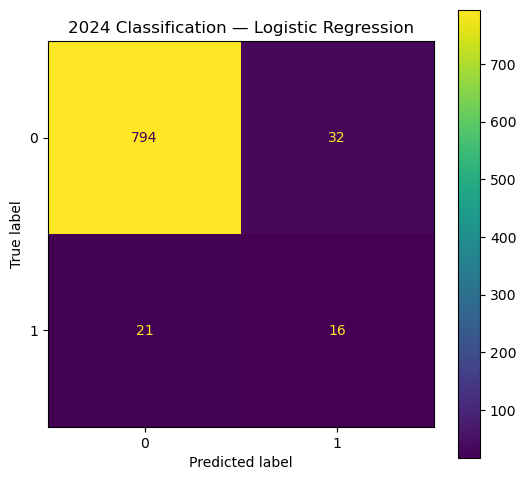

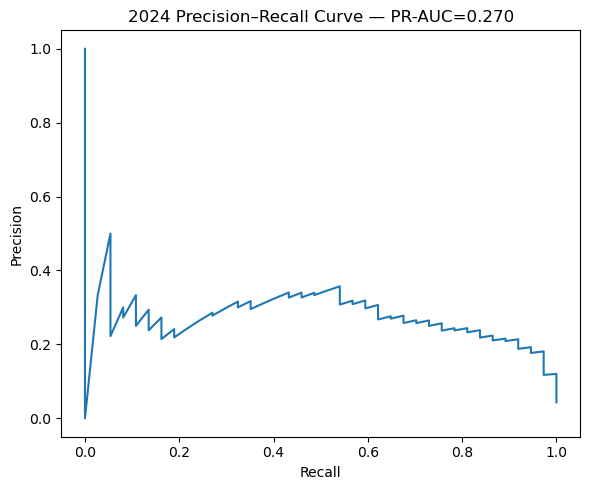

In [7]:
development_cls = pd.concat([train_cls, validation_cls], ignore_index=True)
X_development = development_cls[model_features]
y_development = development_cls[classification_target]

final_classifier = clone(selected_template)
final_classifier.fit(X_development, y_development)

test_probabilities = final_classifier.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= final_threshold).astype(int)

final_metrics = {
    "Model": best_model_name,
    "Config": best_config_id,
    "Threshold": final_threshold,
    **probability_metrics(y_test, test_probabilities),
    **threshold_metrics(y_test, test_probabilities, final_threshold),
}
final_metrics_df = pd.DataFrame([final_metrics])
print("\nFinal 2024 classification performance:")
print(final_metrics_df.round(4).to_string(index=False))
final_metrics_df.to_csv(table_dir / "model1_final_2024_metrics.csv", index=False)

# Confusion matrix.
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax)
ax.set_title(f"2024 Classification — {best_model_name}")
fig.tight_layout()
fig.savefig(figure_dir / "model1_2024_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

# Precision-recall curve.
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probabilities)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"2024 Precision–Recall Curve — PR-AUC={final_metrics['PR_AUC']:.3f}")
fig.tight_layout()
fig.savefig(figure_dir / "model1_2024_precision_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()

In [8]:
classification_predictions = test_cls[["date", "target_date", "station", classification_target]].copy()
classification_predictions["predicted_probability"] = test_probabilities
classification_predictions["predicted_class"] = test_predictions
classification_predictions.to_csv(table_dir / "model1_2024_predictions.csv", index=False)

joblib.dump(final_classifier, model_dir / "model1_classification.joblib")
with open(model_dir / "model1_classification_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": best_model_name,
        "config": best_config_id,
        "threshold": final_threshold,
        "primary_selection_metric": "PR_AUC",
        "threshold_selection_metric": "F1",
        "features": model_features,
    }, f, indent=2)

print("\nSaved classification model, configuration, predictions and figures.")


Saved classification model, configuration, predictions and figures.
